In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
# Set the root path as if it's being ran from the project root
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)

In [31]:
import pygad
import numpy as np
import torch
import os
from ga.components.ga import on_crossover_func, on_generation_func, calculate_dynamic_probs
from ga.components.fitness import constrained_fitness_func
from ga.components.mutation import paper_style_mutation, random_float_mutation, custom_mutation
from ga.components.crossover import pixel_cleaning_operation
from ga.components.model import load_model, evaluate_without_perturbation, evaluate_with_perturbation
from ga.utils import get_dataloader, visualize_images_batch,visualize_image, visualize_perturbation, compute_pixel_statistics, load_config

In [32]:
# Use GPU instead of CPU

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Parameters

In [33]:
config = load_config()

In [34]:
# num_generations =num_generations=config["ga"]["num_generations"]
# num_parents_mating=config["ga"]["num_parents_mating"]
# sol_per_pop=config["ga"]["sol_per_pop"]
# init_range_low=config["ga"]["init_range_low"]
# init_range_high=config["ga"]["init_range_high"]
# mutation_percent_genes=config["ga"]["mutation_percent_genes"]

# model_type = config["model"]["model_type"]
# batch_size = config["model"]["batch_size"]

# visualize = config["visualization"]["visualize"]
# visualize_every = config["visualization"]["visualize_every"]


# Model

In [35]:
model = load_model(config["model"]["model_type"], device=device)

Loading model: googlenet
Using device: mps


# Loading

In [36]:
# Load
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
image_dir = os.path.join(project_root, "nn/data/imagenet/val")
dataloader = get_dataloader(config["model"]["batch_size"], image_dir)


## Compute statistics - no need to run now

In [37]:
# Compute the pixel mean and standard deviation for each pixel across the entire dataset - for constrained fitness func

# pixel_mean, pixel_std = compute_pixel_statistics(dataloader)

# Roughly 0.04, 1.18, since we already normalize the dataset

In [38]:
# First batch
input_batch, labels = next(iter(dataloader))
input_batch, labels = input_batch.to(device), labels.to(device)

# Collect top perturbations from each generation
top_perturbations = []

# GA Config

/Users/OAA/miniforge3/envs/DL/lib/python3.8/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")



Generation 1 completed with fitness: [-3.81377096 -3.78940267 -3.80969381 -3.85231008 -3.85935201 -3.85713338
 -3.79691915 -3.83073263 -3.83076467 -3.79550466 -3.85190267 -3.80100393
 -3.84725332 -3.84821767 -3.84453115 -3.84252309 -3.82375326 -3.85304708
 -3.86680135 -3.78027028 -3.83214101 -3.86787557 -3.81901082 -3.85399618
 -3.80996236 -3.80588064 -3.91647176 -3.84679708 -3.77875204 -3.81537771
 -3.8121993  -3.8758666  -3.87065725 -3.81702566 -3.9151473  -3.80504293
 -3.83742055 -3.81652212 -3.82985067 -3.88530416 -3.82148427 -3.8510848
 -3.83605794 -3.80469808 -3.90513906 -3.82877645 -3.88688497 -3.80850515
 -3.82836599 -3.86934652]
Best Fitness = -3.778752035357363

Best solution snippet: [-0.13114077 -0.32850576 -0.20017326  0.20898915 -0.16020116  0.42951672
  0.44956326  0.15676226 -0.40645819 -0.42093128]
Best solution zeros count: 15114
Best perturbation magnitude: 106.08280181884766
New crossover & mutation probabilities: 0.8921875, 0.59375

Generation 2 completed with fit

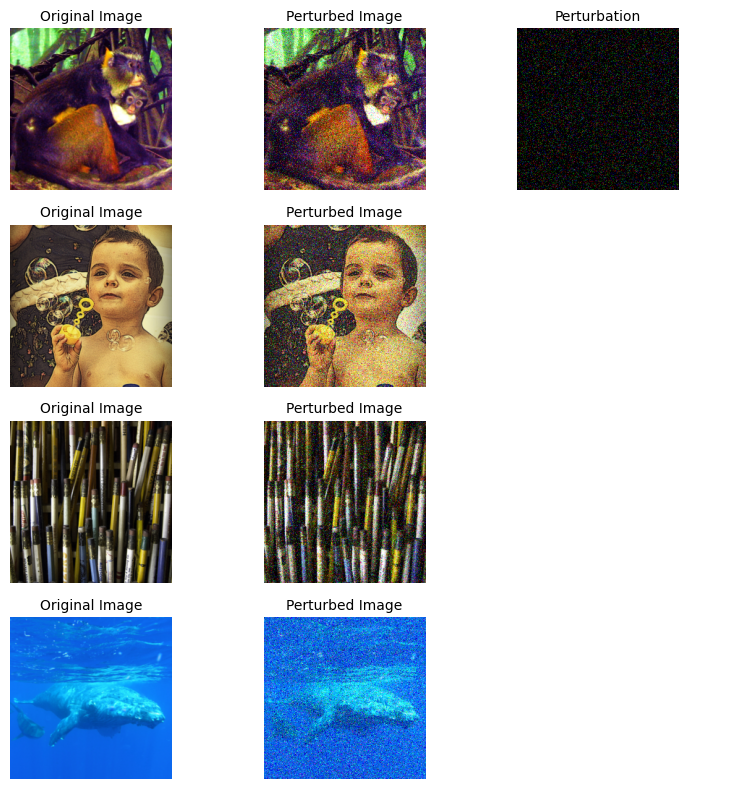

New crossover & mutation probabilities: 0.775, 0.5

Generation 17 completed with fitness: [0.43578212 0.421875   0.38240687 0.4375     0.4114352  0.39750239
 0.40625    0.41815517 0.4375     0.421875   0.453125   0.42540156
 0.453125   0.39181239 0.41517818 0.37370174 0.43236262 0.36524837
 0.43660609 0.38476741 0.453125   0.453125   0.43916194 0.38744685
 0.43708369 0.41885249 0.39917781 0.36870906 0.46875    0.390625
 0.42176387 0.42073085 0.390625   0.39251887 0.46875    0.453125
 0.39023311 0.40466334 0.453125   0.38490016 0.40625    0.4375
 0.40388209 0.390625   0.40113246 0.45878932 0.45197627 0.42299983
 0.46875    0.42137019]
Best Fitness = 0.46875

Best solution snippet: [-0.25727894  0.          0.          0.          0.02614138  0.40324961
  0.37763258  0.         -0.36174238  0.        ]
Best solution zeros count: 96376
Best perturbation magnitude: 66.87651824951172
New crossover & mutation probabilities: 0.7671875, 0.49374999999999997

Generation 18 completed with fitness

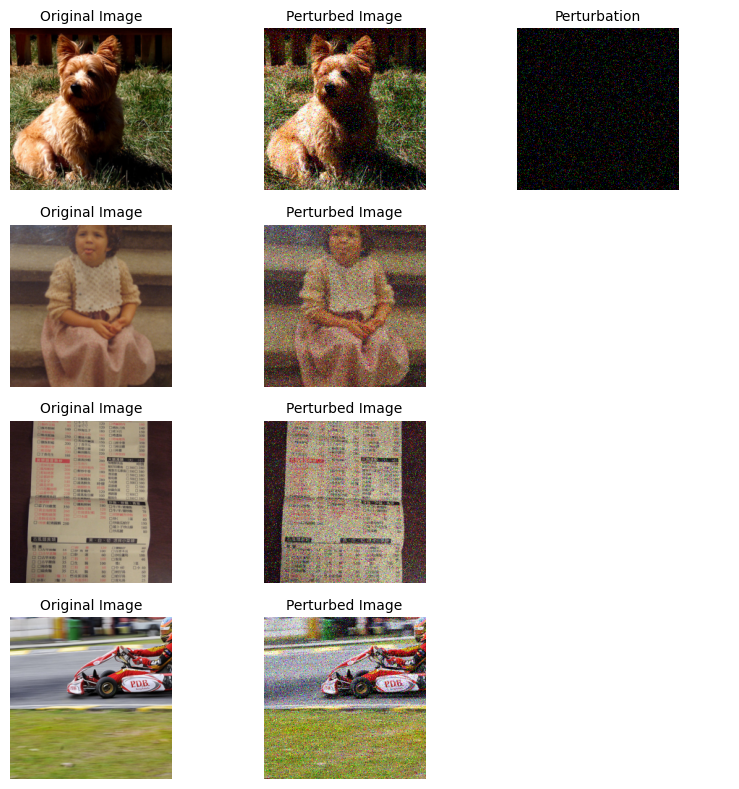

New crossover & mutation probabilities: 0.65, 0.4

Generation 33 completed with fitness: [0.5625     0.51670165 0.59375    0.578125   0.578125   0.59375
 0.41723037 0.59375    0.5452478  0.45590377 0.5625     0.33368087
 0.59375    0.5625     0.578125   0.59375    0.5625     0.57472854
 0.5625     0.625      0.51030593 0.609375   0.48675475 0.546875
 0.578125   0.54170776 0.51859222 0.578125   0.59307266 0.42663131
 0.59375    0.51388412 0.5625     0.55113006 0.53830963 0.5625
 0.5625     0.46795135 0.54032073 0.578125   0.5625     0.53191696
 0.42154632 0.59375    0.45829864 0.53721023 0.31791091 0.578125
 0.578125   0.5625    ]
Best Fitness = 0.625

Best solution snippet: [0.         0.         0.         0.         0.         0.
 0.37763258 0.         0.         0.        ]
Best solution zeros count: 117514
Best perturbation magnitude: 52.166542053222656
New crossover & mutation probabilities: 0.6421875, 0.39375

Generation 34 completed with fitness: [0.57236387 0.578125   0.609375 

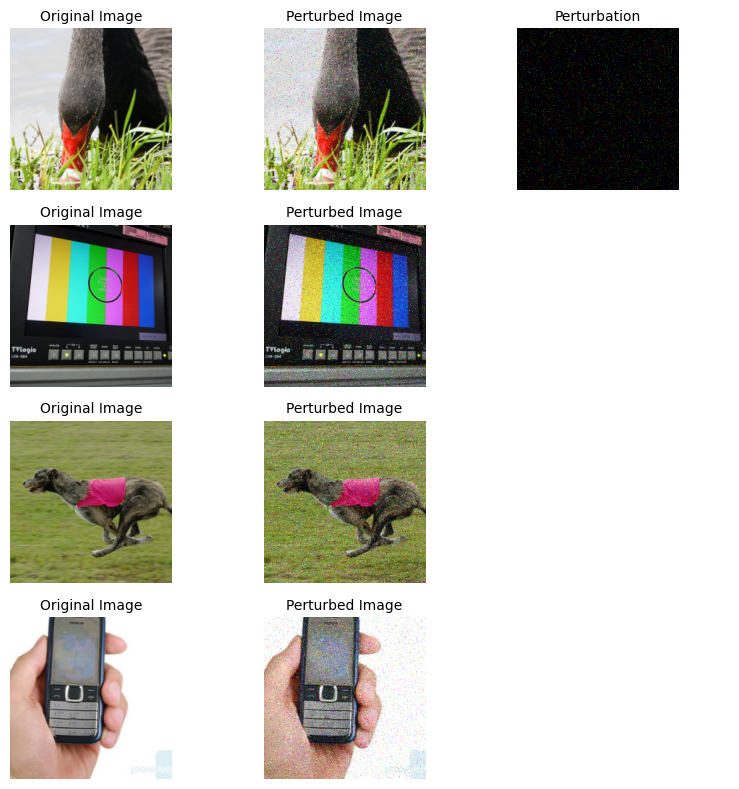

New crossover & mutation probabilities: 0.525, 0.3

Generation 49 completed with fitness: [0.625      0.49410269 0.5988024  0.39930441 0.625      0.37819769
 0.53569434 0.41696036 0.5625     0.41321509 0.625      0.58243048
 0.56431067 0.40124991 0.35869162 0.45416739 0.47624609 0.33390829
 0.59375    0.40810339 0.37528479 0.55088065 0.49939368 0.59475577
 0.60596259 0.54543097 0.51800406 0.609375   0.54781897 0.42048361
 0.35396216 0.39992926 0.53743613 0.47667868 0.39585974 0.45738165
 0.35136053 0.52762701 0.41778357 0.47060263 0.49021857 0.52360861
 0.55877859 0.45964148 0.40916922 0.55524084 0.48242285 0.42657721
 0.39574606 0.43181326]
Best Fitness = 0.625

Best solution snippet: [0.         0.         0.         0.         0.         0.40324961
 0.37763258 0.         0.         0.        ]
Best solution zeros count: 128469
Best perturbation magnitude: 42.72407913208008
New crossover & mutation probabilities: 0.5171875, 0.29375

Generation 50 completed with fitness: [0.59375    0

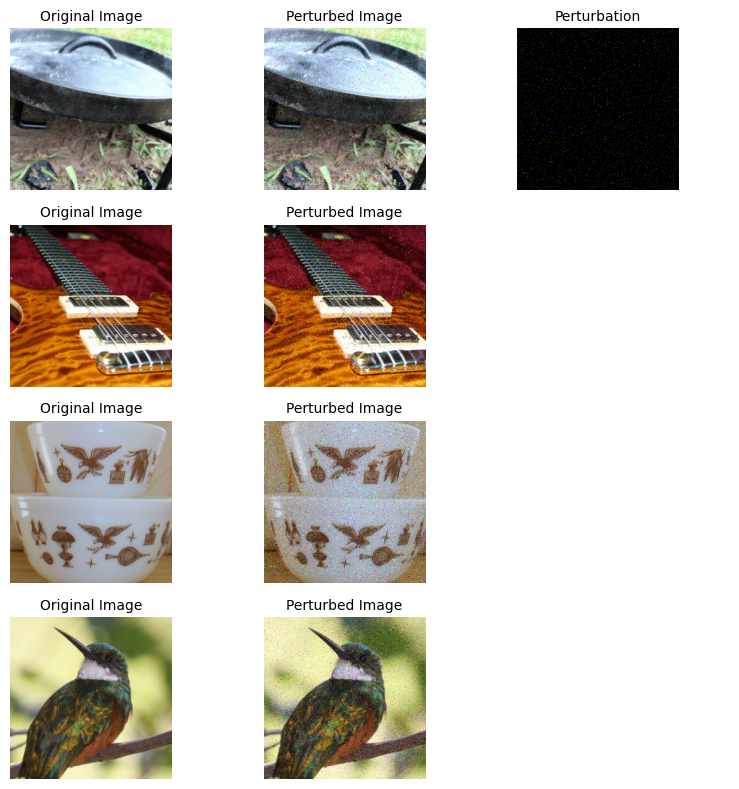

New crossover & mutation probabilities: 0.4, 0.2


In [91]:
config = load_config()
top_perturbations = []

ga_instance = pygad.GA(
    num_generations=config["ga"]["num_generations"],
    num_parents_mating=config["ga"]["num_parents_mating"],
    sol_per_pop=config["ga"]["sol_per_pop"],
    num_genes=3*224*224,
    gene_type=float,
    init_range_low=config["ga"]["init_range_low"],
    init_range_high=config["ga"]["init_range_high"],
    parent_selection_type=config["ga"]["parent_selection_type"],
    keep_elitism=config["ga"]["keep_elitism"],
    keep_parents=config["ga"]["keep_parents"],
    crossover_type=config["crossover"]["crossover_type"],
    crossover_probability=config["crossover"]["p_crossover_init"],
    mutation_type=lambda ga_inst, offspring: paper_style_mutation(ga_inst, offspring, config["mutation"]["p_mutation_init"], config["mutation"]["p_flip"]),
    fitness_func=lambda ga_inst, solution, solution_idx: constrained_fitness_func(
        ga_inst, solution, solution_idx, model, config["fitness"]["epsilon_init"], config["fitness"]["epsilon_end"], config["fitness"]["penalty_factor"]
    ),
    on_generation=lambda ga_inst: on_generation_func(ga_inst, dataloader, device, config),
    on_crossover=lambda ga_inst, offspring: on_crossover_func(ga_inst, offspring, config),
)

ga_instance.user_data={
    "input_batch": input_batch,
    "labels": labels,
    "top_perturbations": top_perturbations,
    "epsilon": config["fitness"]["epsilon_init"]
}

ga_instance.run()

In [52]:
# After the run
solution, solution_fitness, _ = ga_instance.best_solution()
print(f"Best solution fitness: {solution_fitness}") # Might be the penultimate best fitness??

Best solution fitness: 0.5625


# Calculating Universal Perturbation

In [84]:
top_perturbations = ga_instance.user_data["top_perturbations"]
len(top_perturbations)

64

torch.Size([3, 224, 224])
Universal perturbation created.


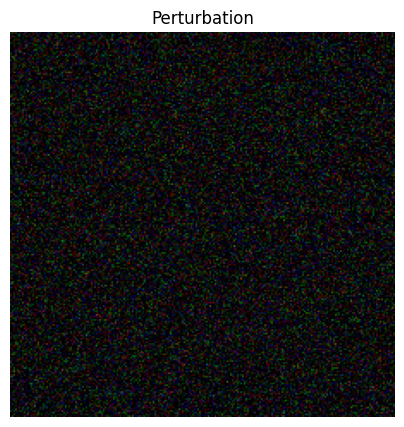

In [140]:
# Stacking the top perturbations together

# if len(top_perturbations) > 0:
#     universal_perturbation = torch.mean(torch.stack(top_perturbations), dim=0)
#     print(universal_perturbation.shape)
#     print(f"Universal perturbation created.")
#     visualize_perturbation(universal_perturbation)

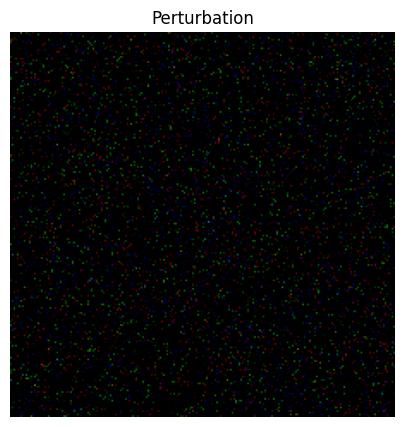

In [94]:
# Take the last one only (much smaller norm)
universal_perturbation = top_perturbations[63]
visualize_perturbation(universal_perturbation)

# Metrics

### GoogLeNet
(4 min)

In [155]:
evaluate_without_perturbation(model, dataloader, device)
# 0.6977

Using device: mps
Accuracy without perturbation: 0.69772


0.69772

In [95]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)
# 9/24: 0.37964

# 12/24: 0.39556 (mean (higher norm)), 0.4017 (last one only)

Using device: mps
Accuracy with perturbation: 0.40932


0.40932

### ViT b 16

In [ ]:
evaluate_without_perturbation(model, dataloader, device)
# 0.811
# 13 mins

Using device: cpu


RuntimeError: Mismatched Tensor types in NNPack convolutionOutput

In [ ]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)